In [412]:
%matplotlib inline

# Importando pacotes básicos:

In [413]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz

## Configurando as saídas dos gráficos:

In [414]:
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 15, 4
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['figure.figsize'] = 17, 17

# Testando a análise com um sinal sintético 
## Formas de ondas criadas através da convolução de senos e ruído branco

# -----------------------
#  Criar sinal sintético
# -----------------------

1. **Características dos sinais sintéticos**

In [440]:
# Parâmetros do tempo
fs = 500  # Frequência de amostragem (Hz)
dt = 1 / fs # taxa de amostragem
duration = 2.0  # segundos
t = np.arange(0, duration, dt) # vetor de tempo de duração

# Frequências desejadas na modelagem
f1 = 1    # Hz
f2 = 10   # Hz
f3 = 30   # Hz
f4 = 60   # Hz

2. **Variável com sinal sintético criado através da convolução de três senos e ruído branco:**

In [448]:
# Gerar senóides
sine1 = np.sin(2 * np.pi * f1 * t)
sine2 = np.sin(2 * np.pi * f2 * t)
sine3 = np.sin(2 * np.pi * f3 * t)
sine4 = np.sin(2 * np.pi * f4 * t)

# Sinal combinado
signal = sine1 + sine2 + sine3 + sine4

In [449]:
npts = len(signal)

In [450]:
freqs = np.fft.rfftfreq(n, d=dt)
fft_orig = np.abs(np.fft.rfft(signal))

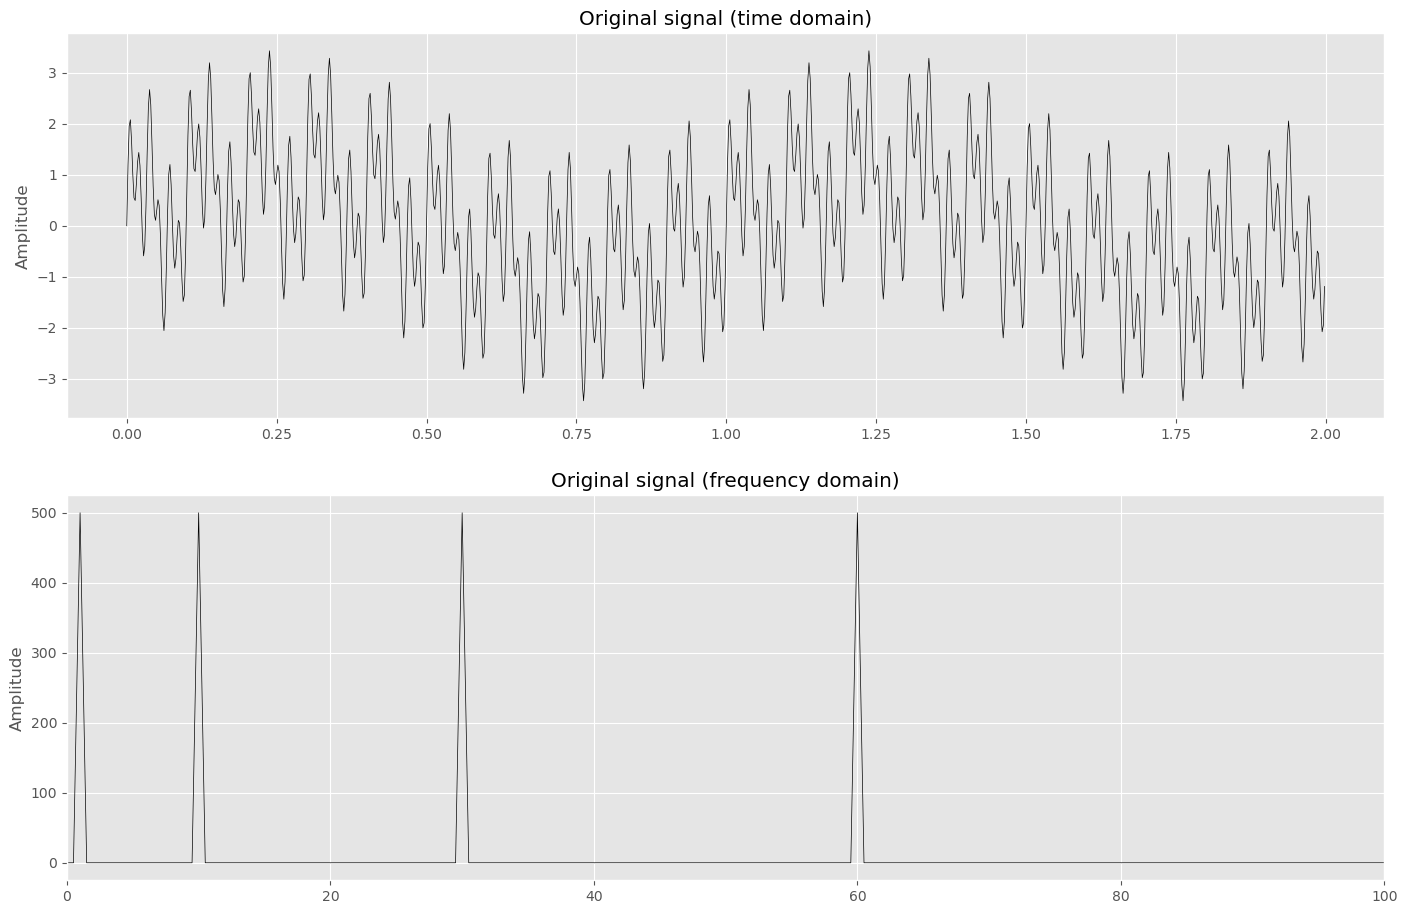

In [451]:
fx2 = 100

fig = plt.figure()

# Original
ax1 = fig.add_subplot(3,1,1)
ax1.plot(t, signal, 'k')
ax1.set_title('Original signal (time domain)')
ax1.set_ylabel('Amplitude')

ax3 = fig.add_subplot(3,1,2)
ax3.plot(freqs, fft_orig, 'k')
ax3.set_title('Original signal (frequency domain)')
ax3.set_ylabel('Amplitude')
ax3.set_xlim(0, fx2)
plt.show()

# ------------------------
#  Parâmetros dos filtros
# ------------------------

- **Filtro Butterworth**
  - A resposta em frequência de um filtro Butterworth é plana na banda passante, e se aproxima do zero na banda rejeitada.


    1.  Ordem do filtro (número de polos). Valores maiores tornam o filtro mais "agudo"

In [452]:
corners = 4  

    2. Frequência de corte para filtro passa-baixa ou passa-alta (em Hz)

In [453]:
f0 = 15

    3. Frequência máxima e mínima da banda para o primeiro filtro passa-banda (em Hz)

In [454]:
fmin1 = 5.0
fmax1 = 60.0

    4. Frequência máxima e mínima da banda para o segundo filtro passa-banda (em Hz)

In [455]:
fmin2 = 5.0
fmax2 = 60.0

In [456]:
def butter_filter(freqs, btype, fs, order):
    """
    Projetar um filtro Butterworth e retornar seus coeficientes.

    Parâmetros
    ----------
    freqs : float ou lista de float
        Frequência de corte (para 'low' e 'high') ou
        [corte_inferior, corte_superior] (para 'bandpass' e 'bandstop'), em Hz.
    btype : {'low', 'high', 'bandpass', 'bandstop'}
        Tipo de filtro a ser projetado.
    fs : float
        Frequência de amostragem do sinal, em Hz.
    order : int
        Ordem do filtro. Ordens maiores produzem uma transição mais abrupta na banda de passagem.

    Retornos
    --------
    b : ndarray
        Coeficientes do polinômio do numerador do filtro (parte feedforward).
    a : ndarray
        Coeficientes do polinômio do denominador do filtro (parte feedback).

    Notas
    -----
    O filtro é projetado utilizando o método Butterworth da biblioteca SciPy.
    As frequências de corte são automaticamente normalizadas pela frequência de Nyquist.

    Exemplos
    --------
    >>> b, a = butter_filter(0.04, 'low', fs=100.0, order=4)
    >>> from scipy.signal import filtfilt
    >>> y = filtfilt(b, a, x)  # Aplica o filtro de fase zero ao sinal x
    """
    
    nyq = 0.5 * fs  # Frequência de Nyquist
    if btype in ['low', 'high']:
        normal_cutoff = freqs / nyq
    else:  # bandpass ou bandstop
        normal_cutoff = [f / nyq for f in freqs]

    b, a = butter(order, normal_cutoff, btype=btype)
    return b, a

- **Aplicar filtros com filtfilt (zero-phase)**

1. **Filtro passa-baixa:** remove componentes de alta frequência acima de f0

In [457]:
b_lp, a_lp = butter_filter(f0, 'low', fs, corners)      # Calcula coeficientes do filtro passa-baixa
signal_lp = filtfilt(b_lp, a_lp, signal)                # Aplica o filtro ao sinal (fase zero)

2. **Filtro passa-alta:** remove componentes de baixa frequência abaixo de f0

In [458]:
b_hp, a_hp = butter_filter(f0, 'high', fs, corners)     # Calcula coeficientes do filtro passa-alta
signal_hp = filtfilt(b_hp, a_hp, signal)                # Aplica o filtro ao sinal (fase zero)

3. **Filtro passa-banda:** mantém somente as frequências entre fmin1 e fmax1

In [459]:
b_bp, a_bp = butter_filter([fmin1, fmax1], 'bandpass', fs, corners)  # Coeficientes do passa-banda
signal_bp = filtfilt(b_bp, a_bp, signal)                            # Aplica filtro ao sinal

4. **Filtro rejeita-banda (ou notch):** remove frequências entre fmin2 e fmax2

In [460]:
b_bs, a_bs = butter_filter([fmin2, fmax2], 'bandstop', fs, corners) # Coeficientes do rejeita-banda
signal_bs = filtfilt(b_bs, a_bs, signal)                            # Aplica filtro ao sinal

# -----------
#  Espectros
# -----------

- Gera os valores de frequência correspondentes à FFT real unilateral

In [461]:
freqs = np.fft.rfftfreq(npts, d=dt)

- Calcula o módulo da FFT (espectro de amplitudes) do sinal original

In [462]:
fft_orig = np.abs(np.fft.rfft(signal))

- Calcula o módulo da FFT do sinal filtrado com passa-baixa

In [463]:
fft_lp = np.abs(np.fft.rfft(signal_lp))

- Calcula o módulo da FFT do sinal filtrado com passa-alta

In [464]:
fft_hp = np.abs(np.fft.rfft(signal_hp))

- Calcula o módulo da FFT do sinal filtrado com passa-banda

In [465]:
fft_bp = np.abs(np.fft.rfft(signal_bp))

- Calcula o módulo da FFT do sinal filtrado com rejeita-banda (notch)

In [466]:
fft_bs = np.abs(np.fft.rfft(signal_bs))

# ----------
#  Plotagem
# ----------

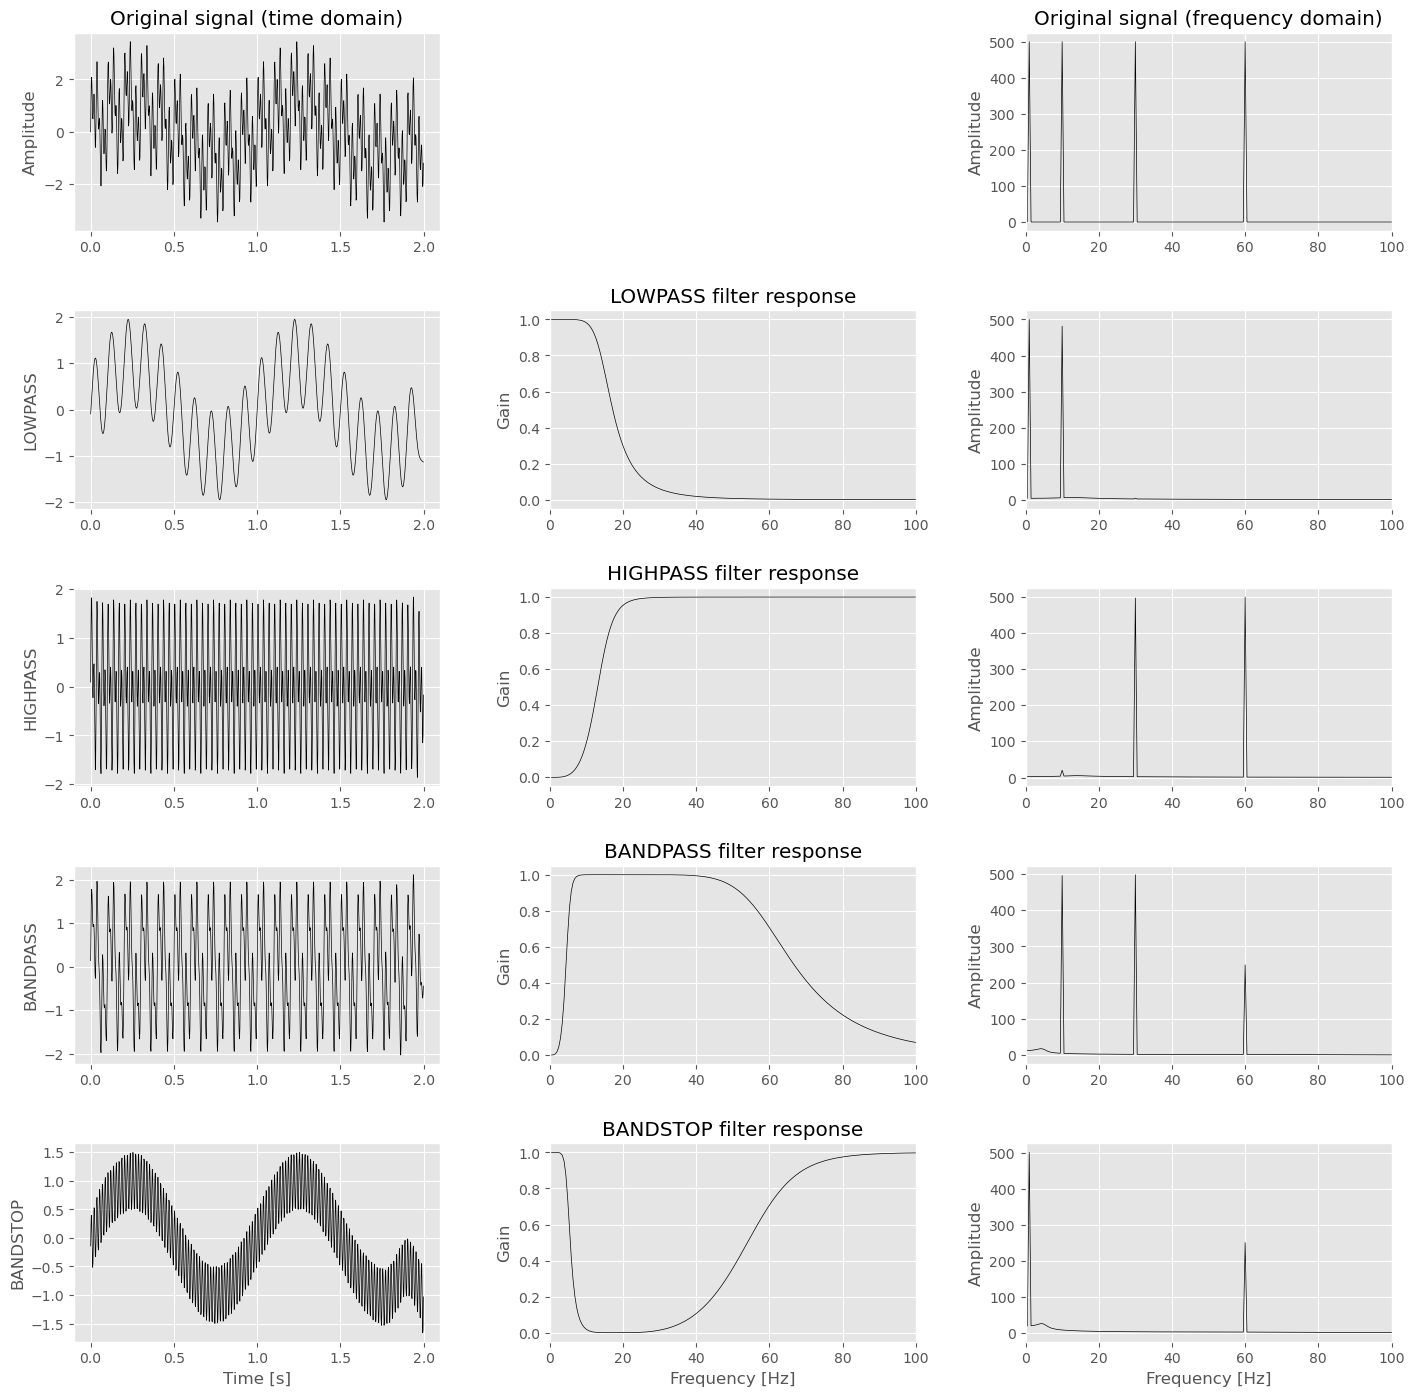

In [467]:
fx2 = 100

fig = plt.figure()

# Original
ax1 = fig.add_subplot(5,3,1)
ax1.plot(t, signal, 'k')
#ax1.set_xlim(tx1, tx2)
ax1.set_title('Original signal (time domain)')
ax1.set_ylabel('Amplitude')

ax3 = fig.add_subplot(5,3,3)
ax3.plot(freqs, fft_orig, 'k')
ax3.set_title('Original signal (frequency domain)')
ax3.set_ylabel('Amplitude')
ax3.set_xlim(0, fx2)

# LOWPASS
ax4 = fig.add_subplot(5,3,4)
ax4.plot(t, signal_lp, 'k')
#ax4.set_xlim(tx1, tx2)
ax4.set_ylabel('LOWPASS')

ax5 = fig.add_subplot(5,3,5)
w, h = butter_filter(f0, 'low', fs, corners)
w, h = freqz(b_lp, a_lp, worN=512, fs=fs)
ax5.plot(w, abs(h), 'k')
ax5.set_xlim(0, fx2)
ax5.set_title('LOWPASS filter response')
ax5.set_ylabel('Gain')

ax6 = fig.add_subplot(5,3,6)
ax6.plot(freqs, fft_lp, 'k')
ax6.set_ylabel('Amplitude')
ax6.set_xlim(0, fx2)

# HIGHPASS
ax7 = fig.add_subplot(5,3,7)
ax7.plot(t, signal_hp, 'k')
ax7.set_ylabel('HIGHPASS')

ax8 = fig.add_subplot(5,3,8)
w, h = freqz(b_hp, a_hp, worN=512, fs=fs)
ax8.plot(w, abs(h), 'k')
ax8.set_xlim(0, fx2)
ax8.set_ylabel('Gain')
ax8.set_title('HIGHPASS filter response')


ax9 = fig.add_subplot(5,3,9)
ax9.plot(freqs, fft_hp, 'k')
ax9.set_ylabel('Amplitude')
ax9.set_xlim(0, fx2)

# BANDPASS
ax10 = fig.add_subplot(5,3,10)
ax10.plot(t, signal_bp, 'k')
ax10.set_ylabel('BANDPASS')

ax11 = fig.add_subplot(5,3,11)
w, h = freqz(b_bp, a_bp, worN=512, fs=fs)
ax11.plot(w, abs(h), 'k')
ax11.set_xlim(0, fx2)
ax11.set_ylabel('Gain')
ax11.set_title('BANDPASS filter response')

ax12 = fig.add_subplot(5,3,12)
ax12.plot(freqs, fft_bp, 'k')
ax12.set_ylabel('Amplitude')
ax12.set_xlim(0, fx2)

# BANDSTOP
ax13 = fig.add_subplot(5,3,13)
ax13.plot(t, signal_bs, 'k')
ax13.set_xlabel('Time [s]')
ax13.set_ylabel('BANDSTOP')

ax14 = fig.add_subplot(5,3,14)
w, h = freqz(b_bs, a_bs, worN=512, fs=fs)
ax14.plot(w, abs(h), 'k')
ax14.set_xlim(0, fx2)
ax14.set_ylabel('Gain')
ax14.set_xlabel('Frequency [Hz]')
ax14.set_title('BANDSTOP filter response')

ax15 = fig.add_subplot(5,3,15)
ax15.plot(freqs, fft_bs, 'k')
ax15.set_xlabel('Frequency [Hz]')
ax15.set_ylabel('Amplitude')
ax15.set_xlim(0, fx2)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()
